# Uczenie głębokie 


## laboratorium: Autopenkoder w keras

Najważniejsze koncepcje :
-   Autoenkdoer
-   Enkoder i dekoder w keras

### This Person Does Not Exist

https://thispersondoesnotexist.com


## Dane

In [2]:
import tensorflow as tf
import numpy as np
import keras

TRAIN_BUF = 60000
BATCH_SIZE = 256

TEST_BUF = 10000
latent_dim=8

np_savez_data = np.load('./traffic_set1.npz')
x_train = np_savez_data['x_train']
y_train = np_savez_data['y_train']
x_valid = np_savez_data['x_valid']
y_valid = np_savez_data['y_valid']

x_train = x_train[y_train > 0,:]
y_train = y_train[y_train > 0]
x_valid = x_valid[y_valid > 0,:]

ds = tf.data.Dataset.from_tensor_slices(x_train)
ds=ds.shuffle(TRAIN_BUF)

def fun(x):
  #y = tf.image.rgb_to_hsv(tf.cast(x, tf.float32)/255.)
  y = tf.cast(x, tf.float32)/255.
  return (y,y)


ds = ds.map(fun)
ds = ds.batch(BATCH_SIZE)

testds = tf.data.Dataset.from_tensor_slices(x_valid)
testds = testds.map(fun)
testds = testds.batch(BATCH_SIZE)

In [3]:
x_train.shape, y_train.shape,x_valid.shape

((1067, 64, 64, 3), (1067,), (461, 64, 64, 3))

# Zadania

1. Zaimplementowac enkoder, przyjmujący na wejście paczkę zdjęć i generujacy paczkę wektorów o wymiarze `latent_dim`.



In [4]:
#TODO
encoder = keras.Sequential([
    keras.layers.Conv2D(
        filters=32, kernel_size=3, strides=(2, 2), activation="relu"),
    keras.layers.Conv2D(
        filters=64, kernel_size=3, strides=(2, 2), activation="relu"),
    keras.layers.Flatten(),
    keras.layers.Dense(latent_dim)
])   

# Zadania

1. Zaimplementowac decoder



In [6]:
decoder = keras.Sequential([
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(units=8*8*32, activation="relu"),

    keras.layers.Reshape(target_shape=(8, 8, 32)),
    keras.layers.Conv2DTranspose(
        filters = 32, 
        kernel_size = 3, 
        strides=(2, 2), 
        padding="same", 
        activation="relu"),
        keras.layers.Conv2DTranspose(
            filters = 32,
            kernel_size = 3,
            strides=(2, 2),
            padding="same",
            activation="relu"),
        keras.layers.Conv2DTranspose(
            filters = 64,
            kernel_size = 3,
            strides=(2, 2),
            padding="same",
            activation="relu"),

keras.layers.Conv2DTranspose(
        filters = 3,
        kernel_size = 1,
        strides=(1, 1),
        padding="same",
        activation=keras.activations.sigmoid,
        bias_initializer=keras.initializers.Constant(0.5)
        )
])

## Zadanie

Zbudowac autoenkdoer wykorzystując funkcyjne api keras

In [7]:
input = keras.layers.Input(shape=(64, 64, 3))
h = encoder(input)
output = decoder(h)

autoencoder = keras.Model(input, output)

## Zadanie trening

- Wytrenowac model `autoencoder` 
Wykorzystać  `Adam(0.001)` i `MeanSquaredError` loss

1. Trenowac model przez min 80 epok
1. Walidowac model aby dostrzec przeuczenie

In [ ]:
#TODO

In [8]:
autoencoder.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.MeanSquaredError())
history = autoencoder.fit(ds, epochs=80, verbose=1, validation_data=testds)

Epoch 1/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 817ms/step - loss: 0.2131 - val_loss: 0.2082
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 809ms/step - loss: 0.2080 - val_loss: 0.1957
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 707ms/step - loss: 0.1802 - val_loss: 0.1353
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 750ms/step - loss: 0.1257 - val_loss: 0.1286
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 703ms/step - loss: 0.1235 - val_loss: 0.1231
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 726ms/step - loss: 0.1141 - val_loss: 0.1103
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 695ms/step - loss: 0.1011 - val_loss: 0.1007
Epoch 8/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 685ms/step - loss: 0.0958 - val_loss: 0.0950
Epoch 9/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 701ms/step - loss: 0.0897 - val_loss: 0.0881
Epoch 10/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 686ms/step - loss: 0.0823 - val_loss: 0.0777
Epoch 11/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 682ms/step - loss: 0.0728 - val_loss: 0.0691
Epoch 12/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 850ms/step - loss: 0.0653 - val_lo

<Axes: >

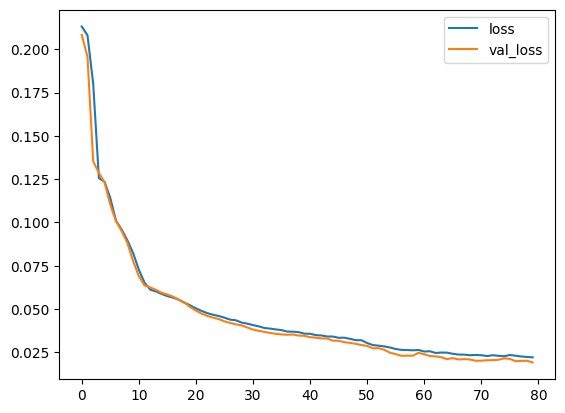

In [9]:
import pandas as pd

pd.DataFrame(history.history).plot()

In [10]:
autoencoder.save('autoencoder.keras')

## Wizualizacja

Zobaczmy kilka losowych wejść i rekonstrukcji


In [ ]:
#TODO


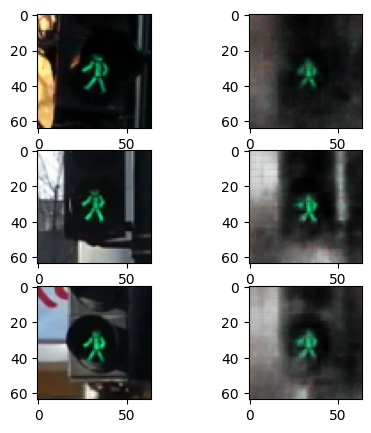

In [11]:
import matplotlib.pyplot as plt
import random
kmax=3
fig,ax=plt.subplots(kmax,2,figsize=(5,5))


n=0
k=random.randint(0,300)

new_x = x_valid[k:k+kmax]


compressed = autoencoder(fun(new_x)[0])
for n in range(kmax):
    ax[n,0].imshow(new_x[n,:])
    ax[n,1].imshow( compressed[n,:])
plt.show()


## Generacja

Wygenerować nowe zdjecie z losowego punktu



In [12]:
h=encoder(fun(x_valid)[0])
mu = np.mean(h, axis=0)
sigma = np.cov(h.numpy().T)

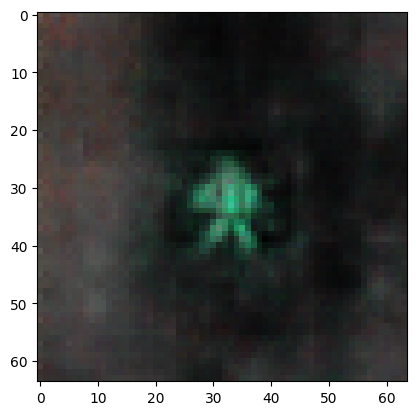

In [13]:

random_h = np.random.multivariate_normal(mu, sigma, size=1)
img = decoder(random_h)
plt.imshow(( img[0,:]))